In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [29]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

In [30]:
# 3. Arquitectura del Modelo
class Generator(nn.Module):
    def __init__(self, z_dim, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2), # LeakyReLU ayuda a evitar gradientes moribundos
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, img_dim),
            nn.Tanh() # Salida en rango [-1, 1]
        )

    def forward(self, x):
        return self.net(x).view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid() # Salida de probabilidad [0, 1]
        )

    def forward(self, x):
        return self.net(x.view(-1, 28*28))

In [31]:
z_dim = 100
image_dim = 28 * 28 * 1
lr = 0.0002

G = Generator(z_dim, image_dim).to(device)
D = Discriminator(image_dim).to(device)

criterion = nn.BCELoss() # Binary Cross Entropy Loss
opt_G = optim.Adam(G.parameters(), lr=lr)
opt_D = optim.Adam(D.parameters(), lr=lr)

In [32]:
losses_G = []
losses_D = []
epochs = 20

for epoch in range(epochs):
    for i, (real, _) in enumerate(train_loader):
        real = real.to(device)
        batch_size = real.size(0)

        # Etiquetas (1 = Real, 0 = Falso)
        label_real = torch.ones(batch_size, 1).to(device)
        label_fake = torch.zeros(batch_size, 1).to(device)

        # --- Entrenamiento del Discriminador ---
        opt_D.zero_grad()
        loss_real = criterion(D(real), label_real)

        noise = torch.randn(batch_size, z_dim).to(device)
        fake = G(noise)
        loss_fake = criterion(D(fake.detach()), label_fake)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D.step()

        # --- Entrenamiento del Generador ---
        opt_G.zero_grad()
        output = D(fake)
        loss_G = criterion(output, label_real) # El generador quiere etiquetas de 'Real'

        loss_G.backward()
        opt_G.step()

    losses_D.append(loss_D.item())
    losses_G.append(loss_G.item())
    print(f'Epoch [{epoch+1}/{epochs}] - Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}')

Epoch [1/20] - Loss D: 0.4049, Loss G: 2.7087
Epoch [2/20] - Loss D: 1.8771, Loss G: 2.5813
Epoch [3/20] - Loss D: 0.6171, Loss G: 2.4311
Epoch [4/20] - Loss D: 1.1497, Loss G: 1.5214
Epoch [5/20] - Loss D: 1.2165, Loss G: 1.3107
Epoch [6/20] - Loss D: 0.5043, Loss G: 2.0473
Epoch [7/20] - Loss D: 2.0363, Loss G: 1.3109
Epoch [8/20] - Loss D: 0.7237, Loss G: 3.4475
Epoch [9/20] - Loss D: 0.4297, Loss G: 2.5376
Epoch [10/20] - Loss D: 1.1571, Loss G: 1.9820
Epoch [11/20] - Loss D: 0.5494, Loss G: 3.0472
Epoch [12/20] - Loss D: 1.2396, Loss G: 1.8802
Epoch [13/20] - Loss D: 0.6619, Loss G: 3.6838
Epoch [14/20] - Loss D: 0.8322, Loss G: 3.0134
Epoch [15/20] - Loss D: 1.3446, Loss G: 1.6402
Epoch [16/20] - Loss D: 0.6533, Loss G: 2.0439
Epoch [17/20] - Loss D: 0.7444, Loss G: 3.6652
Epoch [18/20] - Loss D: 0.4762, Loss G: 2.9546
Epoch [19/20] - Loss D: 0.6945, Loss G: 2.8004
Epoch [20/20] - Loss D: 0.4775, Loss G: 3.1412


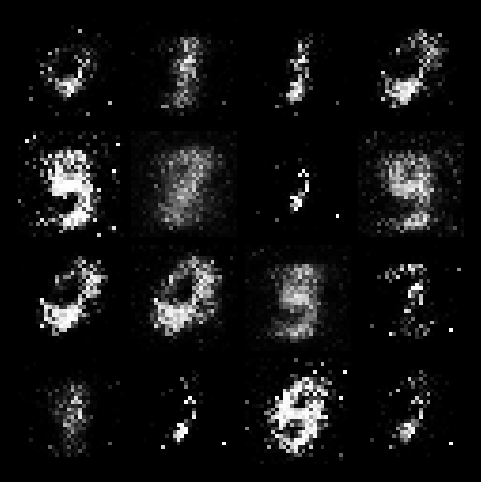

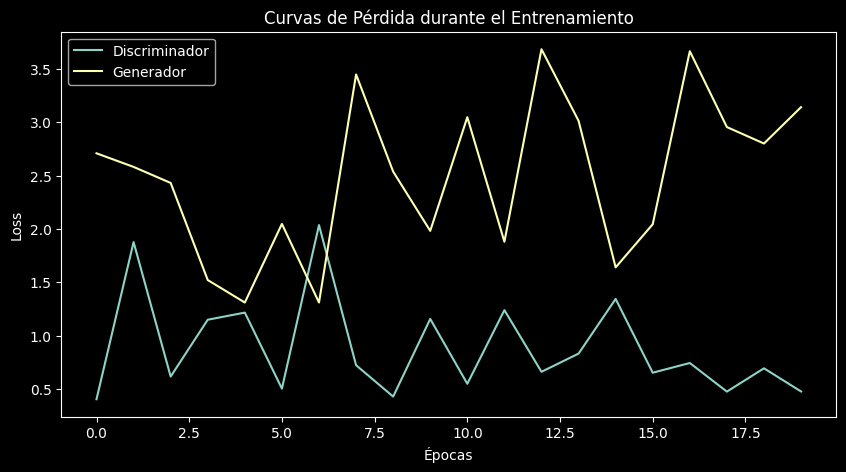

In [33]:
# Función para visualizar imágenes generadas
def show_samples(generator, n_samples=16):
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(n_samples, z_dim).to(device)
        samples = generator(noise).cpu()
        grid = utils.make_grid(samples, nrow=4, normalize=True)
        plt.figure(figsize=(6,6))
        plt.imshow(np.transpose(grid, (1,2,0)))
        plt.axis('off')
        plt.show()

show_samples(G)

# Plot de las curvas de pérdida
plt.figure(figsize=(10,5))
plt.plot(losses_D, label='Discriminador')
plt.plot(losses_G, label='Generador')
plt.title('Curvas de Pérdida durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()